# Приступим к работе :)  

Осталось чууууут-чуууут  

### Загрузка текстов для предобработки, классификации и использования глубокого обучения

In [33]:
import os

import pandas as pd
import spacy
from docx import Document
from docx.document import Document as DocumentType
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt


# Чтение текста из файла
def read_docx(file_path: str) -> str:
    # Считывает текст из файла .docx
    try:
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"Файл {file_path} не найден")

        document = Document(file_path)
        full_text: list[str] = [paragraph.text.strip() for paragraph in document.paragraphs if paragraph.text.strip()]
        return "\n".join(full_text)
    
    except Exception as e:
        print(f"Ошибка при чтении {file_path}: {e}")
        return ""

# Загрузка текста из файлов
def load_docx(dataset_path: str) -> DataFrame:
    # Загружает документы из уазанной директории в DataFrame
    if not os.path.isdir(dataset_path):
        raise NotADirectoryError(f"Директория {dataset_path} не найдена")

    documents = []
    for file_name in sorted(os.listdir(dataset_path)):
        if file_name.startswith("~$") or not file_name.lower().endswith(".docx"):
            continue
        file_path = os.path.join(dataset_path, file_name)
        text = read_docx(file_path)
        if text:
            doc_type = 0 if file_name.startswith("tz_") else 1
            documents.append((file_name, text, doc_type))
        
    df = pd.DataFrame(documents, columns=["doc", "text", "type"])
    df.sort_values(by="doc", inplace=True)
    return df
    

# Пути
project_root = os.path.abspath(os.getcwd())
# project_root: str = os.path.abspath(os.path.join(os.path.dirname("lab8.ipynb"), ".."))
dataset_path: str = os.path.join(project_root, "static", "pmu")

# Загрузка данных
try:
    df = load_docx(dataset_path)
    df.info()

    # Вывод первых строк данных
    display(df.head())
except Exception as e:
    print(f"Ошибка загрузки данных: {e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   doc     58 non-null     object
 1   text    58 non-null     object
 2   type    58 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.5+ KB


,doc,text,type
0,31-АнисинРС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1
1,31-АфанасьевСС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1
2,31-БакальскаяЕД.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1
3,31-БарсуковПО.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1
4,31-БелянинНН.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1


### Предобработка текстов

In [34]:
import nltk
import re
import unicodedata
from typing import Set

from num2words import num2words
from nltk.corpus import stopwords
from spacy.tokens.doc import Doc

# Загрузка модели Spacy. Модель для русского языка
spacy = spacy.load("ru_core_news_lg")

nltk.download("punkt")
nltk.download("stopwords")
stop_woards = set(stopwords.words("russian"))

# Список стоп-слов 
stop_woards: Set[str] = spacy.Defaults.stop_words

# Предобработка текста. Метод для предобработки текста
def preprocess_text(text):
    # Приведение текста к нижнему регистру
    text = text.lower()
    
    # Замена переносов на пробел
    text = text.replace("\n", " ")
    
    # Удаление всех символов, кроме букв и пробелов
    text = re.sub(r"[^a-zA-Za-яА-Я ]", "", text)

    # Удаление диакритических знаков
    text = unicodedata.normalize("NFKD", text)
    text = "".join([char for char in text if not unicodedata.combining(char)])

    # Преобразование чисел в слова
    words: list[str] = text.split()
    words = [num2words(word, lang="ru") if word.isdigit() else word for word in words]
    text = " ".join(words)

    # Токенизация с использованием Spacy
    document = spacy(text)

    # Удаление стоп-слов и пунктуации
    tokens = [token.text for token in document if token.text not in stop_woards and not token.is_stop 
              and not token.is_punct and not token.is_digit]
    
    return " ".join(tokens)


# Применение метода предобработки к загруженному тексту в DataFrame
df["preprocessed_text"] = df["text"].apply(preprocess_text)

# Вывод первых строк DataFrame с предобработанными текстами
display(df.head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nikbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,doc,text,type,preprocessed_text
0,31-АнисинРС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...
1,31-АфанасьевСС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...
2,31-БакальскаяЕД.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...
3,31-БарсуковПО.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...
4,31-БелянинНН.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...


## Нормализация текста (Лемматизация и Стемминг)  

In [35]:
from nltk.stem import PorterStemmer

# Функция Стемминга текста
def stemming_text(text: str) -> str:
    stemmer = PorterStemmer()
    stemmed_word = [stemmer.stem(word) for word in text.split()]
    return " ".join(stemmed_word)

# Функция Лемматизации текста
def lemmatization_text(text: str) -> str:
    doc = spacy(text)
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    return " ".join(lemmas)


# Применение метода предобработки к каждому тексту в DataFrame
df["stemming_text"] = df["preprocessed_text"].apply(stemming_text)
df["lemmatized_text"] = df["preprocessed_text"].apply(lemmatization_text)

# Вывод первых строк DataFrame с предобработанными текстами
display(df.head())

,doc,text,type,preprocessed_text,stemming_text,lemmatized_text
0,31-АнисинРС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...
1,31-АфанасьевСС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...
2,31-БакальскаяЕД.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...
3,31-БарсуковПО.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...
4,31-БелянинНН.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...


### Фильтрация текста

In [36]:
# Функция фильтрации текста
def filter_text(text: str, min_length: int = 3, max_length: int = 15) -> str:
    words = text.split()

    # Удаление слов, где длина либо меньше минимального, либо больше
    return " ".join(word for word in words if min_length <= len(word) <= max_length)

# Применение фильтрации к лемматизированным текстам
df["filtered_text"] = df["lemmatized_text"].apply(filter_text)

# Вывод первых строк DataFrame с отфильтрованными текстами
display(df.head())

,doc,text,type,preprocessed_text,stemming_text,lemmatized_text,filtered_text
0,31-АнисинРС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...
1,31-АфанасьевСС.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...
2,31-БакальскаяЕД.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...
3,31-БарсуковПО.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...
4,31-БелянинНН.docx,МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИ...,1,министерство науки высшего образования россиис...,министерство науки высшего образования россиис...,министерство наука высокий образование россиис...,министерство наука высокий образование россиис...


### Векторизация

In [37]:
from scipy.sparse._matrix import spmatrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Создание объекта TfidVectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.85, sublinear_tf=True)

# Применяем векторизацию к отфильтрованным фильтрам
tfidf_matrix: spmatrix = tfidf_vectorizer.fit_transform(df["filtered_text"])

# Преобразуем результат в DataFrame для удобства
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Вывод первые строки результата
display(tfidf_df.head())

# Преобразуем тексты в списки индексов
X = tfidf_df
y = np.random.randint(0, 2, size=X.shape[0])

# Кластеризация KMeans
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(tfidf_matrix)

print("Кластеры созданы:", clusters)

,abbreviated,abilities,aboba,about,abrath,acceleration,accent,accept,access,accidentally,...,яркии,яркий,яркооранжевым,ярлык,ярусин,ярускин,ярускина,ясно,ясный,яшин
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.023694,0.069332,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.020470,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Кластеры созданы: [2 2 0 2 2 0 2 2 2 0 2 2 0 1 2 0 2 2 0 0 0 0 2 1 2 0 0 0 2 0 0 0 0 1 1 0 1
 1 1 1 1 1 0 1 1 1 2 2 2 1 2 2 0 0 2 2 1 1]


### Разделение на выборки

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Разделение на выборки
train_indices, test_indices = train_test_split(df.index, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Устанавливаем количество эпох
epochs = 10

# Проектируем архитектуру глубоких нейронных сетей для классификации текстов

### Инициализация Keras

In [39]:
import jax
print(jax.__version__)

import keras
print(keras.__version__)

0.6.0
3.9.0


In [40]:
import os

os.environ["KERAS_BACKEND"] = "jax"
import keras

print(keras.__version__)

from keras.api.models import Sequential
from keras.api.layers import InputLayer, Embedding, SpatialDropout1D, LSTM, Dense, Conv1D, MaxPooling1D, Flatten, GlobalMaxPooling1D, BatchNormalization, Dropout

3.9.0


### Обучим модель классификации: полносвязная модель

In [41]:
model = Sequential()
model.add(Embedding(5000, 64, input_length=X_train.shape[1]))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Для бинарной классификации
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

e:\MII\laboratory\mai\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [42]:
model.summary()

model.build(input_shape=(None, X_train))
    
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

mlp_history = model.fit(X_train, y_train, epochs=epochs, batch_size=32, validation_split=0.2, verbose=1)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 735ms/step - accuracy: 0.6053 - loss: 0.6930 - val_accuracy: 0.3000 - val_loss: 0.6985
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step - accuracy: 0.6157 - loss: 0.6911 - val_accuracy: 0.3000 - val_loss: 0.7003
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step - accuracy: 0.6262 - loss: 0.6888 - val_accuracy: 0.3000 - val_loss: 0.7028
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step - accuracy: 0.5949 - loss: 0.6882 - val_accuracy: 0.3000 - val_loss: 0.7059
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step - accuracy: 0.5949 - loss: 0.6872 - val_accuracy: 0.3000 - val_loss: 0.7127
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step - accuracy: 0.6053 - loss: 0.6856 - val_accuracy: 0.3000 - val_loss: 0.7171
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 494ms/step - accuracy: 0.6157 - loss: 0.6829 - val_accuracy: 0.3000 - val_loss: 0.7223
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step - accuracy: 0.6053 - loss: 0.6824 - val_accuracy: 0.3000 - val_loss:

# Свёрточная модель глубокого обучения

In [43]:
model_cnn = Sequential()
model_cnn.add(Embedding(input_dim=5000, output_dim=128, input_length=X_train.shape[1]))
model_cnn.add(Conv1D(64, kernel_size=5, activation='relu'))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Conv1D(128, kernel_size=5, activation='relu'))
model_cnn.add(MaxPooling1D(pool_size=5))
model_cnn.add(GlobalMaxPooling1D())
model_cnn.add(Dense(64, activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(1, activation='sigmoid')) 

model_cnn.summary()

e:\MII\laboratory\mai\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
model_cnn.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

cnn_history = model_cnn.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5217 - loss: 0.6931 - val_accuracy: 0.4167 - val_loss: 0.6934
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step - accuracy: 0.5435 - loss: 0.6928 - val_accuracy: 0.4167 - val_loss: 0.6938
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step - accuracy: 0.5435 - loss: 0.6927 - val_accuracy: 0.4167 - val_loss: 0.6943
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step - accuracy: 0.5435 - loss: 0.6926 - val_accuracy: 0.4167 - val_loss: 0.6949
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step - accuracy: 0.5435 - loss: 0.6924 - val_accuracy: 0.4167 - val_loss: 0.6954
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 895ms/step - accuracy: 0.5435 - loss: 0.6918 - val_accuracy: 0.4167 - val_loss: 0.6959
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step - accuracy: 0.5435 - loss: 0.6919 - val_accuracy: 0.4167 - val_loss: 0.6963
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step - accuracy: 0.5435 - loss: 0.6915 - val_accuracy: 0.4167 - val_loss: 0.

### Архитектуры глубокой рекуррентной нейронной сети LSTM

In [45]:
lstm_model = Sequential()
lstm_model.add(InputLayer(shape=(100,), dtype="float32"))
lstm_model.add(Embedding(1000, 64))
lstm_model.add(SpatialDropout1D(0.2))
lstm_model.add(LSTM(256, dropout=0.2))
lstm_model.add(Dense(1, activation="sigmoid"))

lstm_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 64)        │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,961 (1.50 MB)

 Trainable params: 392,961 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=4,
    validation_data=(X_test, y_test)
)

Epoch 1/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 100s 100s/step - accuracy: 0.5217 - loss: 0.6925 - val_accuracy: 0.4167 - val_loss: 0.7004
Epoch 2/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 98s 98s/step - accuracy: 0.5435 - loss: 0.6887 - val_accuracy: 0.4167 - val_loss: 0.7096
Epoch 3/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 98s 98s/step - accuracy: 0.5435 - loss: 0.6914 - val_accuracy: 0.4167 - val_loss: 0.7166
Epoch 4/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 101s 101s/step - accuracy: 0.5435 - loss: 0.6893 - val_accuracy: 0.4167 - val_loss: 0.7210


In [47]:
lstm_model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4167 - loss: 0.7210


[0.721043050289154, 0.4166666567325592]

## Визуализация распределения вероятностей результатов модели на валидационной выборке

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


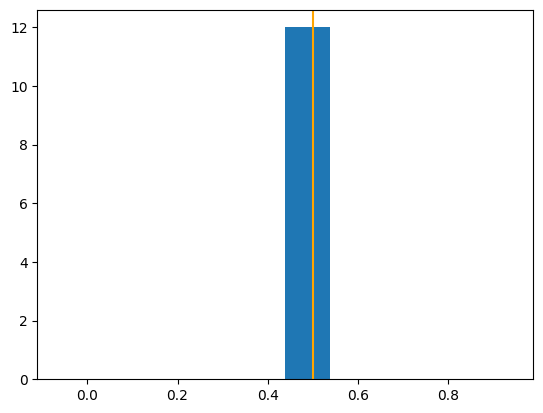

In [48]:
plt.hist(lstm_model.predict(X_test))
_ = plt.axvline(x=0.5, color="orange")

### Сравним модели

In [49]:
# Сравнение моделей
def evaluate_model(model, X_test, y_test):
    # Получаем предсказания
    y_pred = model.predict(X_test)
    
    # Преобразуем предсказания в бинарный формат
    if y_pred.ndim > 1 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)
    else:
        y_pred = (y_pred > 0.5).astype(int).flatten()
    
    # Преобразуем y_test если нужно
    if y_test.ndim > 1 and y_test.shape[1] > 1:
        y_test = np.argmax(y_test, axis=1)
    
    # Вычисляем метрики
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, f1

mlp_accuracy, mlp_f1 = evaluate_model(model, X_test, y_test)
cnn_accuracy, cnn_f1 = evaluate_model(model_cnn, X_test, y_test)
rnn_accuracy, rnn_f1 = evaluate_model(lstm_model, X_test, y_test)

# Вывод результатов
print(f'MLP Accuracy: {mlp_accuracy}, F1 Score: {mlp_f1}')
print(f'CNN Accuracy: {cnn_accuracy}, F1 Score: {cnn_f1}')
print(f'RNN Accuracy: {rnn_accuracy}, F1 Score: {rnn_f1}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
MLP Accuracy: 0.4166666666666667, F1 Score: 0.0
CNN Accuracy: 0.4166666666666667, F1 Score: 0.0
RNN Accuracy: 0.4166666666666667, F1 Score: 0.0


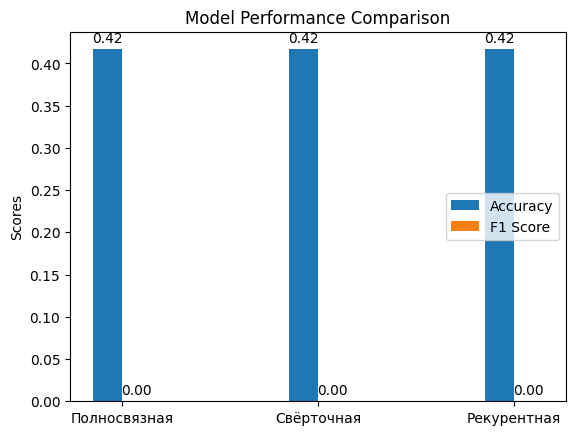

In [50]:
# Построение диаграмм производительности моделей
labels = ['Полносвязная', 'Свёрточная', 'Рекурентная']
accuracy_scores = [mlp_accuracy, cnn_accuracy, rnn_accuracy]
f1_scores = [mlp_f1, cnn_f1, rnn_f1]

x = np.arange(len(labels))  # метки по оси X
width = 0.15  # ширина столбиков

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score')

# Добавление аннотаций
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Отображаем значения на столбиках
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_value_labels(bars1)
add_value_labels(bars2)

plt.show()  # Отображаем график

По результатам метрик, лучше всего себя показала рекурентная за счёт скорости выполнения. Полносвязаная, свёрточная и рекурентная показали одинаково высокие результаты и показатели метрик точности и F1-оценки. В общем можно считать, что модели хорошо справляются с задачей классификации, однако быть полностью уверенными мы не можем, поскольку множество других факторов могут дать иные результаты (н, другие входные данные).

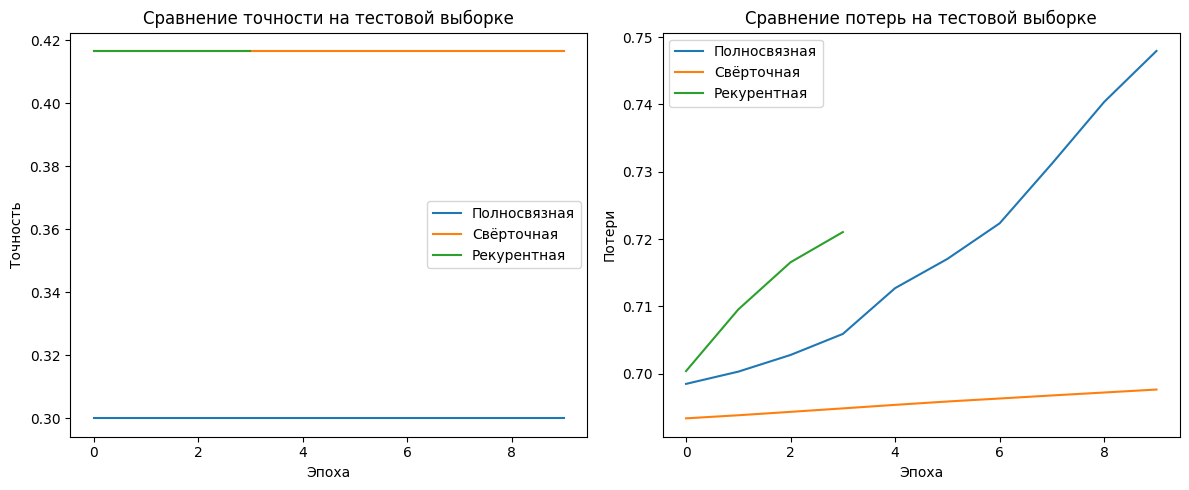

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

Полносвязная - Classification Report:
              precision    recall  f1-score   support

     Class 0       0.42      1.00      0.59         5
     Class 1       0.00      0.00      0.00         7

    accuracy                           0.42        12
   macro avg       0.21      0.50      0.29        12
weighted avg       0.17      0.42      0.25        12

Полносвязная - Accuracy: 0.4167
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

Свёрточная - Classification Report:
              precision    recall  f1-score   support

     Class 0       0.42      1.00      0.59         5
     Class 1       0.00      0.00      0.00         7

    accuracy                           0.42        12
   macro avg       0.21      0.50      0.29        12
weighted avg       0.17      0.42      0.25        12

Свёрточная - Accuracy: 0.4167
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Рекурентная - Classification Report:
              precision    recall  f1-score   support

   

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

def plot_comparison(histories, model_names):
    plt.figure(figsize=(12, 5))
    
    # График точности
    plt.subplot(1, 2, 1)
    for history, name in zip(histories, model_names):
        plt.plot(history.history['val_accuracy'], label=name)
    plt.title('Сравнение точности на тестовой выборке')
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()
    
    # График потерь
    plt.subplot(1, 2, 2)
    for history, name in zip(histories, model_names):
        plt.plot(history.history['val_loss'], label=name)
    plt.title('Сравнение потерь на тестовой выборке')
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Оценка моделей
model_histories = [mlp_history, cnn_history, lstm_history]
model_names = ['Полносвязная', 'Свёрточная', 'Рекурентная']

plot_comparison(model_histories, model_names)

# Вывод метрик
for model, name in zip([model, model_cnn, lstm_model], model_names):
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = y_test
    
    print(f"\n{name} - Classification Report:")
    print(classification_report(
        y_true_classes, 
        y_pred_classes,
        zero_division=0,
        target_names=[f'Class {i}' for i in range(len(np.unique(y_true_classes)))]
    ))
    print(f"{name} - Accuracy: {accuracy_score(y_true_classes, y_pred_classes):.4f}")

In [56]:
from keras.models import Model, Sequential
from keras.layers import Input, Dense
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# Параметры
input_dim = X_train.shape[1]  # Размерность входных данных (TF-IDF)
latent_dim = 64  # Размерность скрытого представления

# Encoder
encoder = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    Dense(latent_dim, activation='relu')
])

# Decoder
decoder = Sequential([
    Dense(512, activation='relu', input_shape=(latent_dim,)),
    Dense(input_dim, activation='sigmoid')
])

# Autoencoder
autoencoder = Sequential([encoder, decoder])
autoencoder.compile(optimizer='adam', loss='mse')

# Обучение
autoencoder.fit(X_train, X_train, 
                epochs=50, 
                batch_size=32, 
                validation_data=(X_test, X_test))

# Извлечение скрытых представлений
latent_representations = encoder.predict(X_train)

# Кластеризация
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(latent_representations)

tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X_train)

Epoch 1/50


e:\MII\laboratory\mai\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - loss: 0.2474 - val_loss: 0.2469
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.2469 - val_loss: 0.2463
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2462 - val_loss: 0.2453
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.2451 - val_loss: 0.2431
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.2424 - val_loss: 0.2373
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.2352 - val_loss: 0.2227
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.2173 - val_loss: 0.1914
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1797 - val_loss: 0.1358
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.1154 - val_loss: 0.0641
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0446 - val_loss: 0.0148
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0064 - val_loss: 0.0018
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 4.0799e-04 - val_loss: 2.6

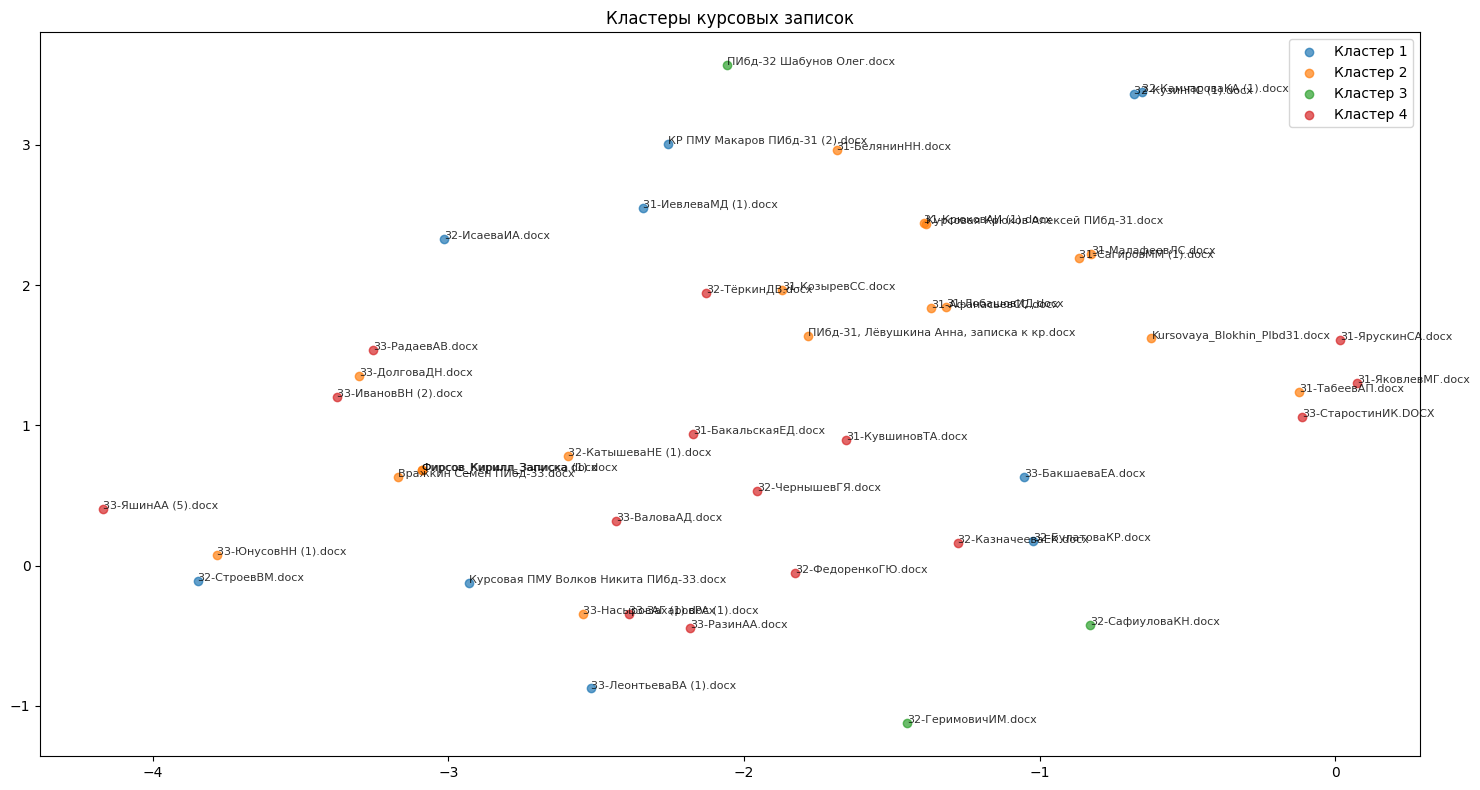

In [102]:
# Визуализация
plt.figure(figsize=(15, 8))
for cluster_id in range(4): 
    indices = kmeans.labels_ == cluster_id
    plt.scatter(X_2d[indices, 0], X_2d[indices, 1], label=f"Кластер {cluster_id + 1}", alpha=0.7)

    for i, doc_name in enumerate(df.loc[train_indices, "doc"].values[indices]):
        x, y = X_2d[indices][i, 0], X_2d[indices][i, 1]
        plt.annotate(doc_name, (x, y), fontsize=8, alpha=0.8)

plt.title("Кластеры курсовых записок")
plt.legend()
plt.tight_layout()
plt.show()


Теперь приступим к анализу изображений. Моих любимых енотов

In [70]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Функция для загрузки изображений из папки на OpenCV
# Функция загрузки изображений
def load_images_from_folder(folder, target_size=(512, 512)):
    images = []
    labels = []
    for label in os.listdir(folder):
        if label in ['Covid', 'Normal', 'Viral Pneumonia']:
            label_folder = os.path.join(folder, label)
            if os.path.isdir(label_folder):
                for filename in os.listdir(label_folder):
                    img_path = os.path.join(label_folder, filename)
                    img = cv2.imread(img_path)
                    if img is not None:
                        img_resized = cv2.resize(img, target_size)
                        images.append(img_resized)
                        labels.append(label)
    return images, labels
# Путь к папке с изображениями
folder_path = "./static/images/X-ray/test"
images, labels = load_images_from_folder(folder_path)

images = np.array(images)
labels = np.array(labels)

In [71]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

### Предобработка изображений  
Буду использовать изменение размера, преобразование в оттенки серого и гистограмму

In [72]:
# Функция предобработки изображений
def preprocess_images(images):
    processed_images = []
    for img in images:

        img_resized = cv2.resize(img, (128, 128))
        # Преобразование в оттенки серого
        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        img_eq = cv2.equalizeHist(img_gray)
        processed_images.append(img_eq.reshape(128, 128, 1))

    return np.array(processed_images)

processed_images = preprocess_images(X_train)

### Аугментация данных  

Аугментируем наши данные, чтобы получить больше входных данных

In [93]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Функция аугментации данных
def augment_data(images, labels):
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    augmented_images = []
    augmented_labels = []

    for label in np.unique(labels):
        label_images = images[labels == label]
        for img in label_images:
            img = img.reshape((1,) + img.shape)
            # Генерация 50 аугментированных изображений
            for _ in range(10):
                aug_iter = datagen.flow(img)
                aug_img = next(aug_iter)[0].astype(np.uint8)
                augmented_images.append(aug_img)
                augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

augmented_images, augmented_labels = augment_data(processed_images, y_train)

### Кодирование меток

In [94]:
from sklearn.preprocessing import LabelEncoder

# Кодировка меток
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(augmented_labels)

# Предобработка тестовых данных
X_test_processed = preprocess_images(X_test)

input_shape = (128, 128, 1)  # Одноканальное изображение
num_classes = len(np.unique(labels))

In [95]:
os.environ["KERAS_BACKEND"] = "torch"

## Создание модели AlexNet

In [96]:
model_AlexNet = models.Sequential()
model_AlexNet.add(layers.Conv2D(96, kernel_size=(11, 11), strides=(4, 4), activation='relu', input_shape=input_shape))
model_AlexNet.add(layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
model_AlexNet.add(layers.Conv2D(256, kernel_size=(5, 5), padding='same', activation='relu'))
model_AlexNet.add(layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
model_AlexNet.add(layers.Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'))
model_AlexNet.add(layers.Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'))
model_AlexNet.add(layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model_AlexNet.add(layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
model_AlexNet.add(layers.Flatten())
model_AlexNet.add(layers.Dense(4096, activation='relu'))
model_AlexNet.add(layers.Dropout(0.5))
model_AlexNet.add(layers.Dense(4096, activation='relu'))
model_AlexNet.add(layers.Dropout(0.5))
model_AlexNet.add(layers.Dense(num_classes, activation='softmax'))

model_AlexNet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

e:\MII\laboratory\mai\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [100]:
# Обучение модели
history = model_AlexNet.fit(augmented_images, y_train_encoded, epochs=20, batch_size=32, validation_data=(X_test_processed, label_encoder.transform(y_test)))

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 24s 210ms/step - accuracy: 0.8630 - loss: 0.3488 - val_accuracy: 0.7935 - val_loss: 0.5501
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 23s 204ms/step - accuracy: 0.8687 - loss: 0.3140 - val_accuracy: 0.7500 - val_loss: 0.5688
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 24s 208ms/step - accuracy: 0.8933 - loss: 0.2805 - val_accuracy: 0.7609 - val_loss: 0.5609
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 194ms/step - accuracy: 0.8685 - loss: 0.3356 - val_accuracy: 0.8043 - val_loss: 0.5688
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 189ms/step - accuracy: 0.9102 - loss: 0.2431 - val_accuracy: 0.8043 - val_loss: 0.5912
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 190ms/step - accuracy: 0.8880 - loss: 0.2799 - val_accuracy: 0.8043 - val_loss: 0.5096
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 194ms/step - accuracy: 0.9269 - loss: 0.1894 - val_accuracy: 0.8587 - val_loss: 0.5168
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 246ms/step - accuracy: 0.9196 - loss: 0

# Оценка результатов

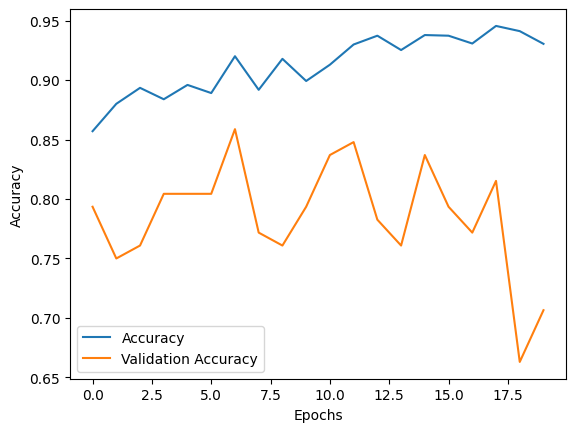

In [101]:
# Визуализация процесса обучения
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()